# 01 - Running HealthSynth

This notebook shows the basic ways to run HealthSynth and inspect the generated datasets.

You will learn:

- how to generate data using the Python API
- how output formats work
- how YAML profiles change behavior
- how to inspect CSV and DuckDB outputs

In [1]:
from healthsynth.generator import generate

In [2]:
datasets = generate(
    hcps=250,
    years=2,
    output_dir="../output/notebook_basic_csv",
    seed=42,
    output_format="csv",
)

In [3]:
datasets.keys()

dict_keys(['hcp_master', 'product', 'call_activity', 'prescriptions', 'market', 'market_share', '_timings'])

In [4]:
for name, df in datasets.items():
    if name != "_timings":
        print(name, df.shape)

hcp_master (250, 12)
product (3, 10)
call_activity (12562, 8)
prescriptions (18000, 7)
market (1, 5)
market_share (72, 6)


In [5]:
datasets["_timings"]

{'simulation': 3.978440300008515,
 'cleanup': 6.510000093840063e-05,
 'csv_export': 0.0526938999973936,
 'validation': 0.018014300003414974,
 'total': 4.049213600010262}

In [6]:
datasets["product"]

,market_id,product_id,product_name,therapeutic_area,launch_date,market,status,manufacturer,brand_type,baseline_market_share
0,MKT_CA,P001,CardioOne,Cardiology,2023-01-01,Canada,Active,NVA Pharma,Innovator,1.0
1,MKT_CA,P002,NeuroMax,Neurology,2022-07-01,Canada,Active,NVA Pharma,Innovator,1.0
2,MKT_CA,P003,EndoCare,Endocrinology,2021-01-01,Canada,Active,NVA Pharma,Innovator,1.0


In [7]:
datasets["hcp_master"].head()

,market_id,hcp_id,hcp_name,specialty,decile,segment,territory_id,territory_name,rep_id,rep_name,city,province
0,MKT_CA,HCP000001,Margaret Hawkins DDS,Neurology,8,High,T014,Territory 014,REP014,Michele Williams,East Lydiamouth,Nova Scotia
1,MKT_CA,HCP000002,Daniel Hahn,Primary Care,7,Medium,T009,Territory 009,REP009,Gabrielle Davis,Jasonfort,Nova Scotia
2,MKT_CA,HCP000003,Maria Thomas,Oncology,10,High,T015,Territory 015,REP015,Dylan Miller,East Julie,Ontario
3,MKT_CA,HCP000004,Kevin Hurst,Cardiology,2,Low,T016,Territory 016,REP016,Brian Ramirez,Coxberg,Ontario
4,MKT_CA,HCP000005,Peter Callahan Jr.,Endocrinology,5,Medium,T004,Territory 004,REP004,Daniel Wagner,Port Erin,Prince Edward Island


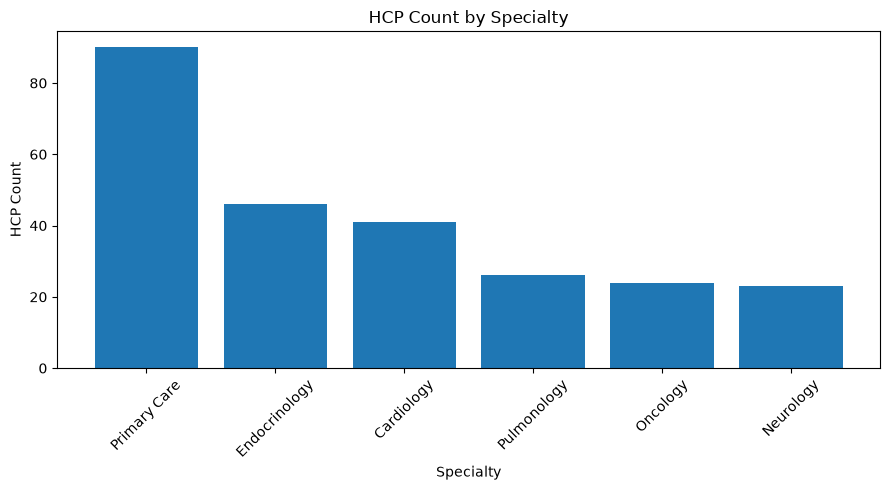

In [8]:
import matplotlib.pyplot as plt

hcp_master = datasets["hcp_master"]

specialty_counts = hcp_master["specialty"].value_counts().reset_index()

specialty_counts.columns = ["specialty", "hcp_count"]

plt.figure(figsize=(9, 5))
plt.bar(specialty_counts["specialty"], specialty_counts["hcp_count"])
plt.title("HCP Count by Specialty")
plt.xlabel("Specialty")
plt.ylabel("HCP Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
duckdb_datasets = generate(
    hcps=250,
    years=2,
    output_dir="../output/notebook_duckdb",
    seed=42,
    output_format="duckdb",
)

In [10]:
import duckdb

con = duckdb.connect("../output/notebook_duckdb/healthsynth.duckdb")
con.execute("SHOW TABLES").fetchdf()

,name
0,call_activity
1,hcp_master
2,market
3,market_share
4,prescriptions
5,product


In [11]:
con.execute("""
SELECT
    p.product_name,
    SUM(rx.nrx) AS total_nrx,
    SUM(rx.trx) AS total_trx
FROM prescriptions rx
JOIN product p
    ON rx.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_nrx DESC
""").fetchdf()

,product_name,total_nrx,total_trx
0,CardioOne,11187.0,30754.0
1,EndoCare,10569.0,29084.0
2,NeuroMax,8489.0,23220.0


In [12]:
oncology = generate(
    config_path="../configs/profiles/oncology_training.yaml",
    output_dir="../output/notebook_oncology",
)

In [13]:
oncology["hcp_master"]["specialty"].value_counts(normalize=True)

specialty
Oncology         0.745
Primary Care     0.106
Cardiology       0.046
Pulmonology      0.046
Neurology        0.031
Endocrinology    0.026
Name: proportion, dtype: float64

In [14]:
oncology["call_activity"]["channel"].value_counts(normalize=True)

channel
Rep Call      0.651052
Email         0.149625
Digital Ad    0.100472
Webinar       0.098851
Name: proportion, dtype: float64

## What you learned

In this notebook, you generated HealthSynth data using:

- direct Python parameters
- CSV output
- DuckDB output
- YAML configuration profiles

This is the foundation for the later notebooks, where we will explore specific commercial analytics use cases.